In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
from scipy import stats

In [5]:
import seaborn as sns

In [6]:
numbers = [45,67,90,69,12, 34, 78, 45]
print(f"Numeros: {numbers}")
print('Estadisticas Descriptivas:')
print(pd.DataFrame(numbers, columns = ['Values']).describe())

Numeros: [45, 67, 90, 69, 12, 34, 78, 45]
Estadisticas Descriptivas:
          Values
count   8.000000
mean   55.000000
std    25.590177
min    12.000000
25%    42.250000
50%    56.000000
75%    71.250000
max    90.000000


In [7]:
mean = np.mean(numbers)

In [8]:
median = np.median(numbers)

In [9]:
mode = stats.mode(numbers)
#Rango
rango = max(numbers) - min(numbers)
iqr = stats.iqr(numbers)
print(f'Media: {mean}\n Mediana: {median} \n')
if mode.count > 1:
    print(f'El valor mas repetido es: {mode.mode}')
else:
    print('No existen valores repetidos en esta lista')
print(f"Rango: {rango}")
print(f'Deteccion de valores atipicos: {iqr}')

Media: 55.0
 Mediana: 56.0 

El valor mas repetido es: 45
Rango: 78
Deteccion de valores atipicos: 29.0


In [10]:
variance = np.var(numbers, ddof=1)
desviation_std = np.std(numbers, ddof=1)
print(f'La varianza es: {variance}')
print(f'La desviacion estandas: {desviation_std}')

La varianza es: 654.8571428571429
La desviacion estandas: 25.590176686712088


In [11]:
cv = (desviation_std/mean) * 100
print(f"Coeficiente de desviacion: {cv}")

Coeficiente de desviacion: 46.52759397584016


In [12]:
print(sorted(numbers))

[12, 34, 45, 45, 67, 69, 78, 90]


In [13]:
print(median)

56.0


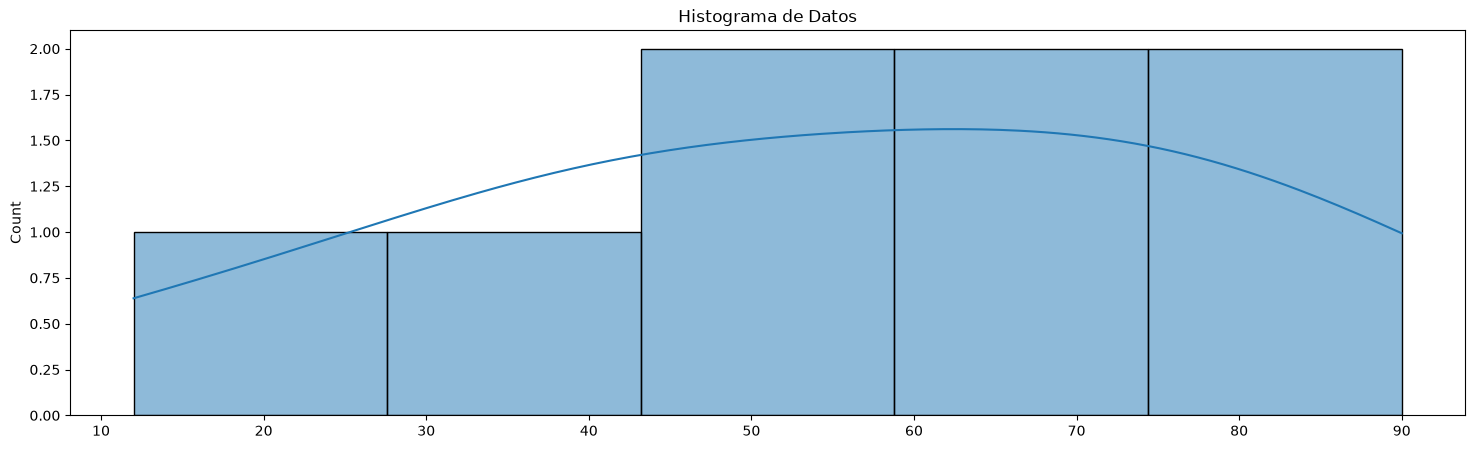

In [14]:
plt.figure(figsize=(18,5))
sns.histplot(numbers, bins=5, kde=True)
plt.title('Histograma de Datos')
plt.show()

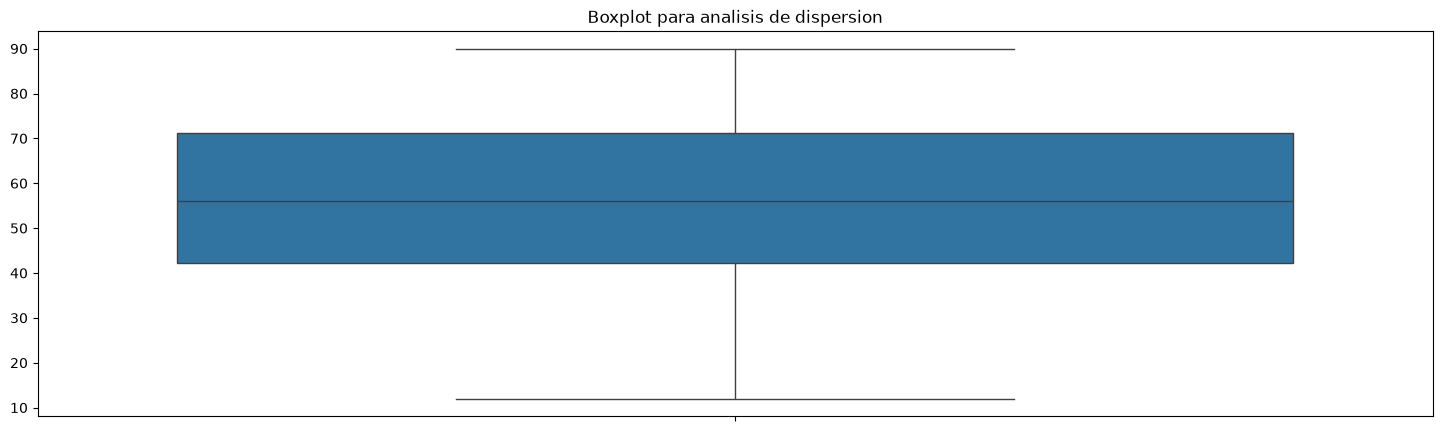

In [15]:
plt.figure(figsize=(18,5))
sns.boxplot(numbers)
plt.title('Boxplot para analisis de dispersion')
plt.show()

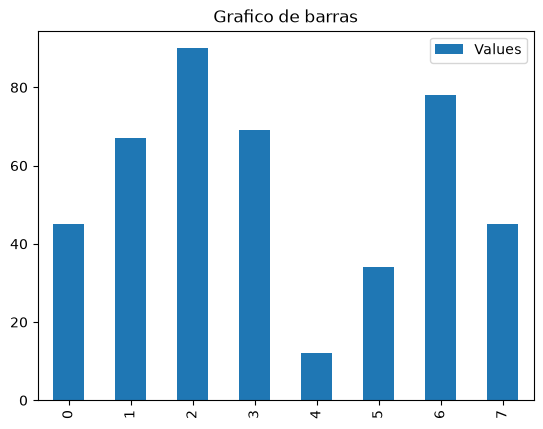

In [16]:
df = pd.DataFrame({"Values": numbers})
df.plot(kind='bar')
plt.title('Grafico de barras')
plt.show()


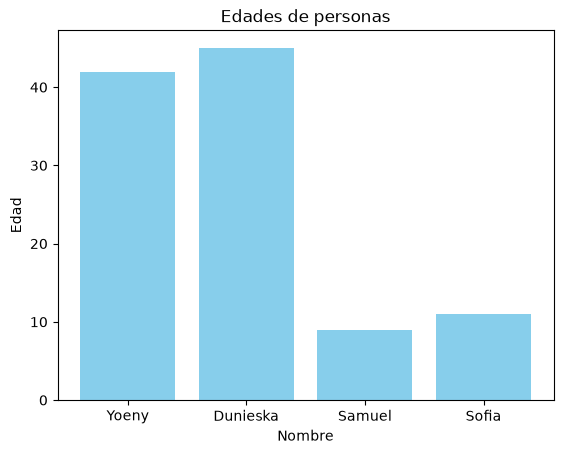

In [17]:
data = {"Name": ['Yoeny', 'Dunieska', 'Samuel', 'Sofia'], 'Edad': [42, 45, 9, 11], 'Altura': [1.67, 1.60, 1, 1.20]}
df = pd.DataFrame(data)
age = df['Edad']
plt.bar(df['Name'], age, color ='skyblue')
plt.title('Edades de personas')
plt.xlabel('Nombre')
plt.ylabel('Edad')
plt.show()

In [18]:
with open('elements.txt', 'w') as a:
    a.write('eres un archivo creado desde aca\n')
    a.write('fin del archivo')

In [19]:
with open('elements.txt', 'r') as a:
    lines = a.readlines()
    print(lines)

['eres un archivo creado desde aca\n', 'fin del archivo']


In [20]:
archive_path = 'adult.csv'
adult = pd.read_csv(archive_path)
adult.head()

FileNotFoundError: [Errno 2] No such file or directory: 'adult.csv'

In [21]:
adult.describe()

NameError: name 'adult' is not defined

In [22]:
adult.tail()

NameError: name 'adult' is not defined

In [23]:
adult.describe(include=['object', 'str'])

NameError: name 'adult' is not defined

In [24]:
adult.info()

NameError: name 'adult' is not defined

In [25]:
adult['age'].describe()

NameError: name 'adult' is not defined

In [26]:
rename_age = adult.rename(columns={'age': 'edad'})
rename_age.head()

NameError: name 'adult' is not defined

In [27]:
delete_columns_education_num = adult.drop(columns=['education.num'])
delete_columns_education_num.head()

NameError: name 'adult' is not defined

In [28]:
group_age = adult.groupby('hours.per.week')['age'].mean()

NameError: name 'adult' is not defined

In [29]:
group_age

NameError: name 'group_age' is not defined

In [30]:
group_age.head()

NameError: name 'group_age' is not defined

In [35]:
db_path = './db_source/'
adult.to_csv(db_path + 'copy_adult.csv', index=False)

In [36]:
df_new = pd.read_csv(db_path + 'copy_adult.csv')

In [37]:
df_new.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [31]:
import pyodbc
import pandas as pd
import os
from dotenv import load_dotenv

In [32]:
load_dotenv()

host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

conexion_str = (
    f'Driver={{ODBC Driver 18 for SQL Server}};'
    f'Server={host},{port};'
    f'Database={db};'
    f'UID={user};'
    f'PWD={password};'
    f'TrustServerCertificate=yes;'
)
conn = pyodbc.connect(conexion_str)
cursor = conn.cursor()

In [33]:
table_name = 'adulto'
load_df = pd.read_csv('./db_source/copy_adult.csv')

In [63]:
create_table_query = f"""
IF NOT EXISTS (SELECT * FROM sys.tables WHERE name = '{table_name}')
BEGIN
    CREATE TABLE {table_name} (
        age int,
        workclass varchar(50),
        fnlwgt int,
        education varchar(50),
        education_num int,
        marital_status varchar(50),
        occupation varchar(50),
        relation_ship varchar(50),
        race varchar(50),
        sex varchar(50),
        capital_gain int,
        capital_lost int,
        hours_per_week int,
        native_country varchar(50),
        income varchar(20)
    )
END
"""

cursor.execute(create_table_query)
conn.commit()

In [69]:
insert_query = f'''INSERT INTO {table_name}
                (age, workclass, fnlwgt, education, education_num, marital_status, occupation, relation_ship, race,
                sex, capital_gain, capital_lost, hours_per_week, native_country, income)
                VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)'''

data = [tuple(row) for _, row in adult.iterrows()]
cursor.executemany(insert_query, data)
conn.commit()
cursor.close()
conn.close()

ProgrammingError: Attempt to use a closed cursor.

In [34]:
new_conn = pyodbc.connect(conexion_str)
select_query = f'''select * from {table_name} where age > ?'''
df = pd.read_sql(select_query, new_conn, params=[30])
new_conn.close()
print(df.shape)
df.head()

/tmp/ipykernel_16671/1452421306.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(select_query, new_conn, params=[30])


(21989, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relation_ship,race,sex,capital_gain,capital_lost,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [35]:
plt.figure(figsize=(10,6))
sex_count = df['sex'].value_counts()

<Figure size 1000x600 with 0 Axes>

Text(0, 0.5, 'Freciencia')

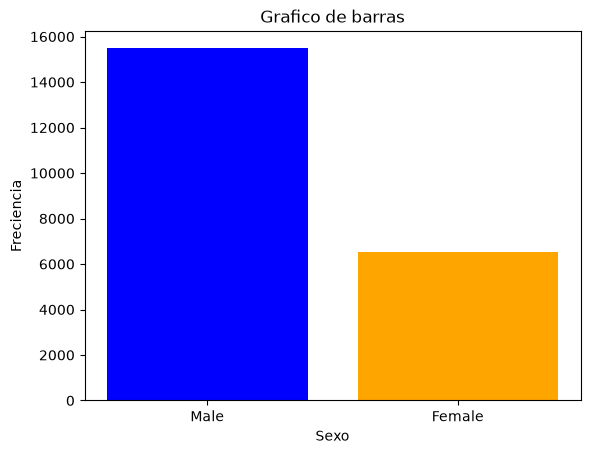

In [16]:
plt.bar(sex_count.index, sex_count.values, color=['blue', 'orange'])
plt.title('Grafico de barras')
plt.xlabel('Sexo')
plt.ylabel('Freciencia')

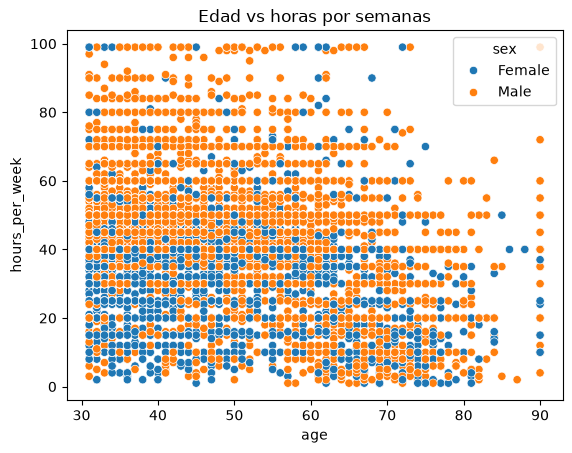

In [17]:
sns.scatterplot(x='age', y='hours_per_week', data=df, hue='sex')
plt.title("Edad vs horas por semanas")
plt.show()

In [18]:
men_age = np.mean(df['age'])

In [19]:
men_age

np.float64(45.573604984310336)

In [20]:
df['age']

0        90
1        82
2        66
3        54
4        41
         ..
21984    43
21985    32
21986    53
21987    40
21988    58
Name: age, Length: 21989, dtype: int64

In [25]:
med = df['age'].median()
med

np.float64(44.0)

In [36]:
count_age_sup_50 = np.sum(df['age']> 50)
count_age_sup_50

np.int64(6460)

In [45]:
import pandas as pd
columns_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

In [46]:
file_path = './db_source/db/iris.data'
df = pd.read_csv(file_path, header=None, names=columns_names)

In [47]:
df.head(50)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [44]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [51]:
df['class'].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [53]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

In [55]:
df.to_csv('./db_source/db/iris_cleaned.data', index=False)